Importing Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Data and assigning headings

In [31]:
df= pd.read_csv(r"C:\Users\elvin\Downloads\auto.csv", header=None)

In [32]:
headers = [
    "symboling","normalized-losses","make","fuel-type","aspiration",
    "num-of-doors","body-style","drive-wheels","engine-location",
    "wheel-base","length","width","height","curb-weight","engine-type",
    "num-of-cylinders","engine-size","fuel-system","bore","stroke",
    "compression-ratio","horsepower","peak-rpm","city-mpg","highway-mpg","price"
]
df.columns= headers

In [33]:
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In this section, we clean the dataset by:
- Replacing "?" with NaN
- Handling missing values (mean/mode)
- Converting datatypes
- Creating new features
- Binning horsepower
- Normalizing a feature

In [34]:
# Replace "?" with NaN (missing value)
df.replace("?", np.nan, inplace=True)

# Check missing values per column
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [35]:
numeric_cols= [
    "normalized-losses","bore","stroke","horsepower","peak-rpm","price"
]

for col in numeric_cols:
    df[col]= pd.to_numeric(df[col], errors="coerce")

In [38]:
for col in numeric_cols:
    df[col]= df[col].fillna(df[col].mean())

df["num-of-doors"]= df["num-of-doors"].fillna(df["num-of-doors"].mode()[0])

df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [39]:
df["price"]= df["price"].astype(float)
df["horsepower"]= df["horsepower"].astype(float)

We now create the required plots:
- Histogram of Price
- Histogram of Horsepower
- Boxplot of Price vs Body Style
- Correlation Heatmap

Text(0, 0.5, 'Frequancy')

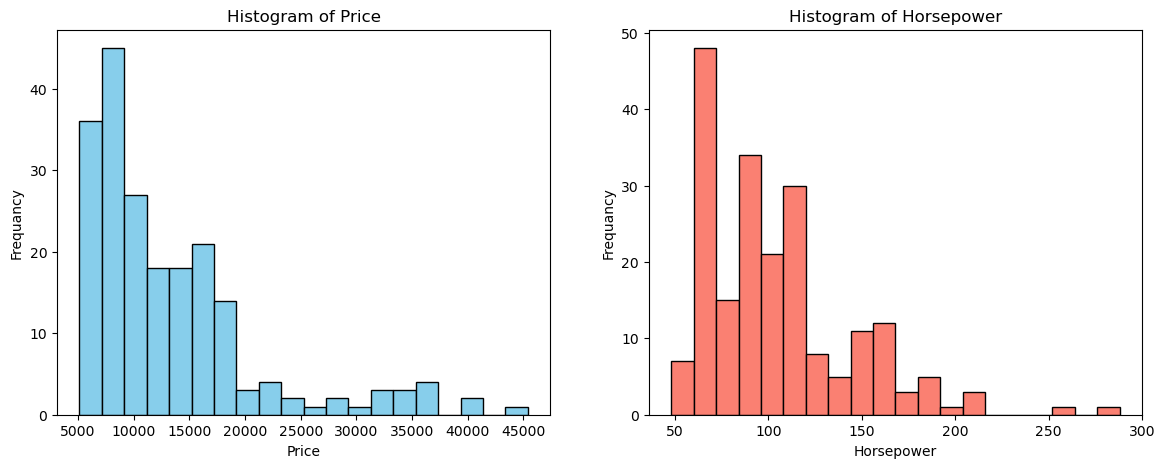

In [45]:
plt.figure(figsize=(14,5))

#Histogram of Price
plt.subplot(1,2,1)
plt.hist(df["price"].dropna(), bins=20, color="skyblue", edgecolor= "black")
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequancy")

#Histogram of Horsepower
plt.subplot(1,2,2)
plt.hist(df["horsepower"].dropna(), bins=20, color="salmon", edgecolor="black")
plt.title("Histogram of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequancy")

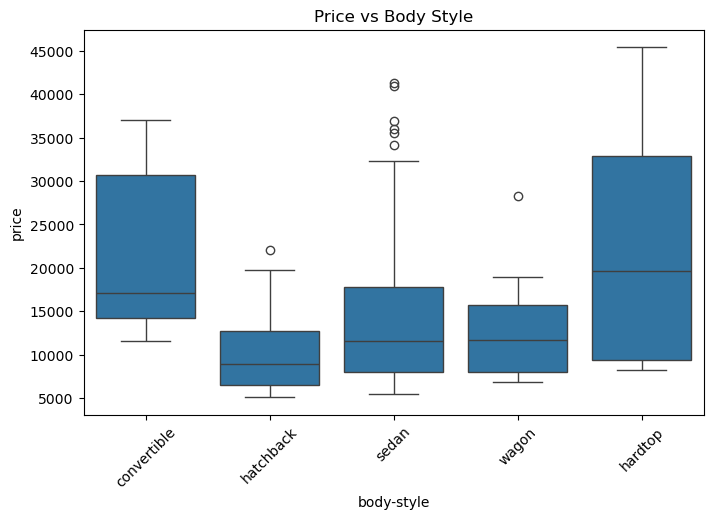

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x="body-style", y="price", data=df)
plt.title("Price vs Body Style")
plt.xticks(rotation=45)
plt.show()

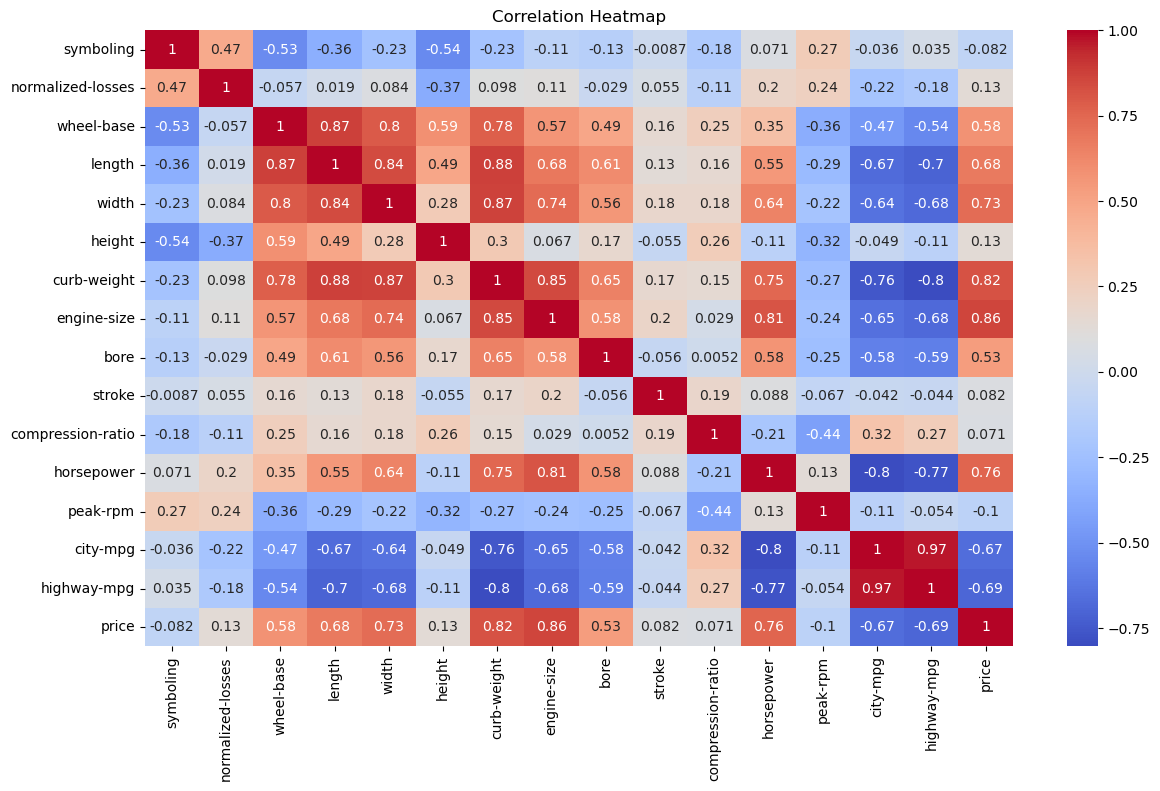

In [52]:
#Select numeric columns only for heatmap
numeric_df= df.select_dtypes(include=["number"])

plt.figure(figsize=(14,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Findings

Engine size and horsepower show strong positive relationships with vehicle price.

Fuel consumption variables also exhibit relationships with price, suggesting that vehicle performance and efficiency influence market value.

These findings support the selection of these variables for predictive modelling.

### Outlier Treatment

Outliers were identified using the IQR method and treated using the capping (Winsorization) technique.

In [53]:
columns = ["price", "horsepower", "engine-size"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

price: 14 outliers
horsepower: 6 outliers
engine-size: 10 outliers


In [54]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [56]:
df["highway-L/100km"] = 235 / df["highway-mpg"]
df[["highway-mpg", "highway-L/100km"]].head()

,highway-mpg,highway-L/100km
0,27,8.703704
1,27,8.703704
2,26,9.038462
3,30,7.833333
4,22,10.681818


In [57]:
df["city-L/100km"] = 235 / df["city-mpg"]
df[["city-mpg", "city-L/100km"]].head()

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


### Applying Binning

In [58]:
bins = [0, 100, 150, df["horsepower"].max()]
labels = ["Low", "Medium", "High"]

df["horsepower-binned"] = pd.cut(
    df["horsepower"], bins=bins, labels=labels, include_lowest=True
)

df[["horsepower", "horsepower-binned"]].head()

,horsepower,horsepower-binned
0,111.0,Medium
1,111.0,Medium
2,154.0,High
3,102.0,Medium
4,115.0,Medium


### Normalizing Engine Size

In [59]:
df["engine-size-normalized"] = df["engine-size"] / df["engine-size"].max()
df[["engine-size", "engine-size-normalized"]].head()

,engine-size,engine-size-normalized
0,130,0.628019
1,130,0.628019
2,152,0.734300
3,109,0.526570
4,136,0.657005


In [62]:
# Select features and target
features = ["engine-size", "horsepower", "city-L/100km", "highway-L/100km"]
X = df[features]
y = df["price"]

In [63]:
# Split data into training and testing sets (80% train, 20% test)

from sklearn.model_selection import train_test_split
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Linear Regression (80/20)

In [65]:
from sklearn.linear_model import LinearRegression
lr_80 = LinearRegression()
lr_80.fit(X_train_80, y_train_80)

# Predictions (80/20)
y_pred_lr_80 = lr_80.predict(X_test_80)

In [72]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluation (80/20)
lr_r2_80 = r2_score(y_test_80, y_pred_lr_80)
lr_mae_80 = mean_absolute_error(y_test_80, y_pred_lr_80)
lr_mse_80 = mean_squared_error(y_test_80, y_pred_lr_80)

print("\n Linear Regression Results (80/20):")
print("R² Score:", lr_r2_80)
print("MAE:", lr_mae_80)
print("MSE:", lr_mse_80)


 Linear Regression Results (80/20):
R² Score: 0.7478805269097568
MAE: 2600.628666210637
MSE: 13100397.619048195


### RandomForest Regression (80/20)

In [71]:
from sklearn.ensemble import RandomForestRegressor

rf_80 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_80.fit(X_train_80, y_train_80)

# Predictions (80/20)
y_pred_rf_80 = rf_80.predict(X_test_80)

# Evaluation (80/20)
rf_r2_80 = r2_score(y_test_80, y_pred_rf_80)
rf_mae_80 = mean_absolute_error(y_test_80, y_pred_rf_80)
rf_mse_80 = mean_squared_error(y_test_80, y_pred_rf_80)

print("\nRandom Forest Results (80/20):")
print("R² Score:", rf_r2_80)
print("MAE:", rf_mae_80)
print("MSE:", rf_mse_80)



Random Forest Results (80/20):
R² Score: 0.9283961178869289
MAE: 1478.938654052552
MSE: 3720614.339111064


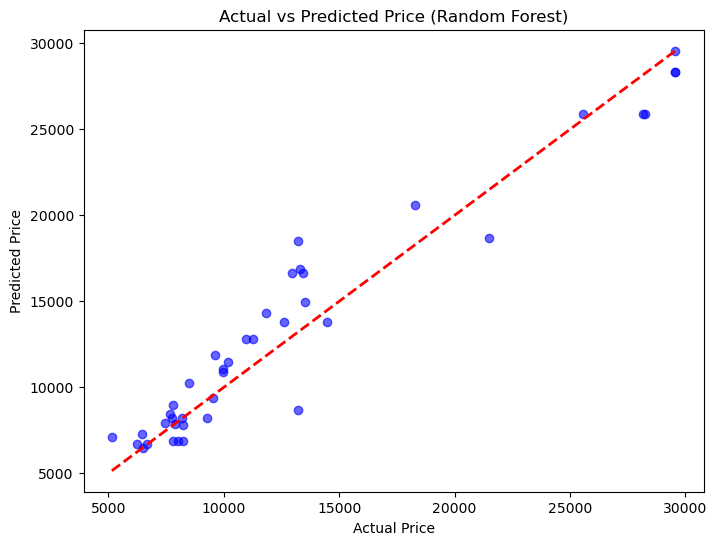

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_80, y_pred_rf_80,color='blue', alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test_80.min(), y_test_80.max()],
    [y_test_80.min(), y_test_80.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

### Comparison of Both Moddels(80/20)

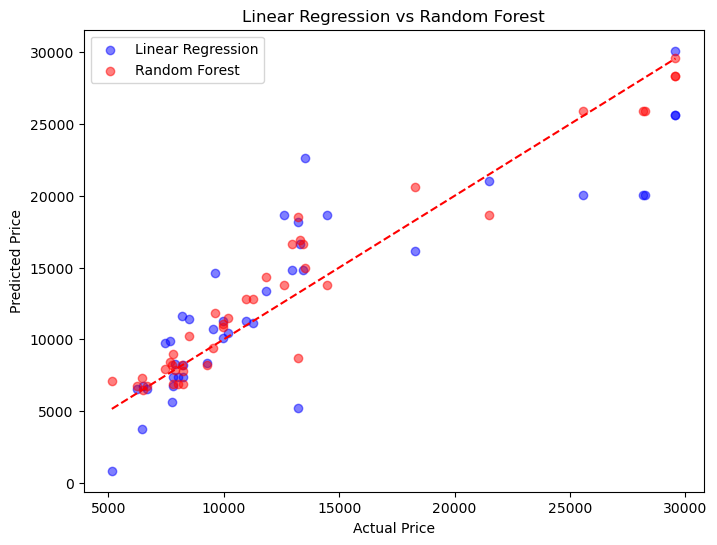

In [74]:
plt.figure(figsize=(8,6))

# Linear Regression
plt.scatter(y_test_80, y_pred_lr_80,color='blue', alpha=0.5, label="Linear Regression")

# Random Forest
plt.scatter(y_test_80, y_pred_rf_80,color='red', alpha=0.5, label="Random Forest")

plt.plot(
    [min(y_test_80), max(y_test_80)],
    [min(y_test_80), max(y_test_80)],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression vs Random Forest")
plt.legend()

plt.show()

## Now we are trying a different split(70/30)

In [77]:
x_train_70,x_test_70,y_train_70,y_test_70= train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Linear Regression (70/20)

In [93]:
lr_70= LinearRegression()
lr_70.fit(x_train_70, y_train_70)
y_pred_lr_70= lr_70.predict(x_test_70)

In [94]:
lr_r2_70= r2_score(y_test_70, y_pred_lr_70)
lr_mae_70= mean_absolute_error(y_test_70,y_pred_lr_70)
lr_mse_70= mean_squared_error(y_test_70, y_pred_lr_70)

print("\nLinear Regression Result (70/30)")
print("R²Score: ",lr_r2_70)
print("MAE: ",lr_mae_70)
print("MSE: ",lr_mse_70)


Linear Regression Result (70/30)
R²Score:  0.7170204766253411
MAE:  2630.8264651300146
MSE:  13047798.283547573


### RandomForest Regression (70/30)

In [96]:
rf_70= RandomForestRegressor(n_estimators=200, random_state=42)
rf_70.fit(x_train_70, y_train_70)
y_pred_rf_70= rf_70.predict(x_test_70)


In [97]:
rf_r2_70= r2_score(y_test_70, y_pred_rf_70)
rf_mae_70= mean_absolute_error(y_test_70, y_pred_rf_70)
rf_mse_70= mean_squared_error(y_test_70, y_pred_rf_70)

print("\nRandomForest Regression (70/30)")
print("R²Score: ", rf_r2_70)
print("MAE: ",rf_mae_70)
print("MSE: ",rf_mse_70)


RandomForest Regression (70/30)
R²Score:  0.8800013063077806
MAE:  1771.8279874193743
MSE:  5532975.428445798


## Bar Chart Comparison of Both splits 80/20 and 70/30

In [98]:
# R² scores
r2_lr_80 = r2_score(y_test_80, y_pred_lr_80)
r2_rf_80 = r2_score(y_test_80, y_pred_rf_80)
r2_lr_70 = r2_score(y_test_70, y_pred_lr_70)
r2_rf_70 = r2_score(y_test_70, y_pred_rf_70)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Linear Regression", "Random Forest"],
    "Split": ["80/20", "80/20", "70/30", "70/30"],
    "R² Score": [r2_lr_80, r2_rf_80, r2_lr_70, r2_rf_70]
})

print(results)

               Model  Split  R² Score
0  Linear Regression  80/20  0.747881
1      Random Forest  80/20  0.928396
2  Linear Regression  70/30  0.717020
3      Random Forest  70/30  0.880001


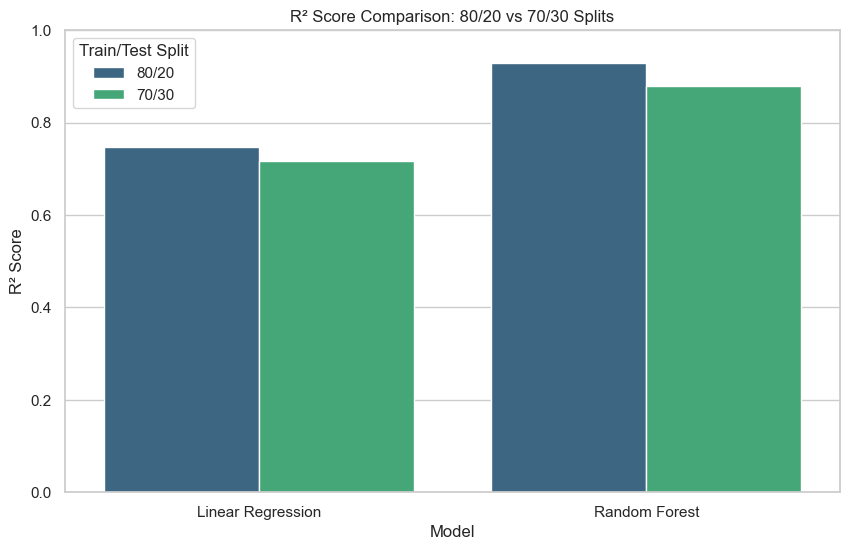

In [100]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(data=results, x="Model", y="R² Score", hue="Split", palette="viridis")
plt.title("R² Score Comparison: 80/20 vs 70/30 Splits")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Train/Test Split")
plt.show()


From all the Train/Test Split Random Forest(80/20) outperformed all models
The Random Forest Regressor performed better than Linear Regression because it was able to capture more complex relationships between the vehicle features and price. Linear Regression assumes a straight-line relationship, while Random Forest can model non-linear patterns that are often present in real-world automobile data.


We convert car prices into categories (Low, Medium, High) and build a Logistic Regression model.
We evaluate the model using:
- Accuracy Score
- Confusion Matrix

In [101]:
# Convert price into categories:
df["price-category"] = pd.qcut(
    df["price"],
    3,
    labels=["Low Price", "Medium Price", "High Price"]
)

In [102]:
x_clf= df[["engine-size", "horsepower", "city-L/100km", "highway-L/100km"]]
y_clf= df["price-category"]

In [103]:
x_train, x_test, y_train, y_test= train_test_split(
    x_clf, y_clf, test_size=0.2, random_state=42
)

In [107]:
from sklearn.linear_model import LogisticRegression
lg= LogisticRegression(max_iter=500)
lg.fit(x_train, y_train)
y_pred= lg.predict(x_test)

C:\Users\elvin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [110]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score= accuracy_score(y_test, y_pred)
cm= confusion_matrix(y_test, y_pred)

print("Accuracy Score: ",accuracy_score)
print("Confussion Matrix: \n", cm)


Accuracy Score:  0.7073170731707317
Confussion Matrix: 
 [[ 9  0  0]
 [ 0 12  3]
 [ 6  3  8]]


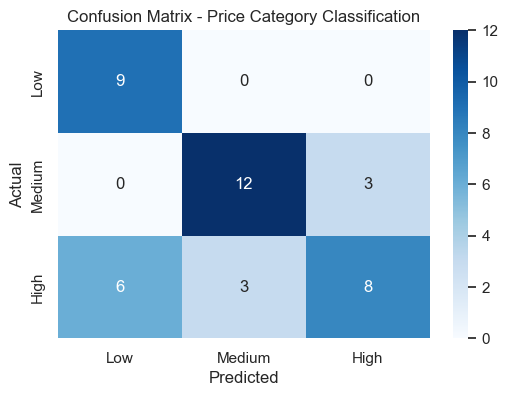

In [111]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.title("Confusion Matrix - Price Category Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Findings

The Logistic Regression model successfully classified vehicles into low, medium, and high price categories.
The confusion matrix indicates that most vehicles were correctly categorized, demonstrating that vehicle characteristics contain sufficient information to predict price ranges.